# Fig. 4 — Xenium mouse brain data analysis

Reproduces Fig. 4b-k; Fig. 4a is the Allen Reference Atlas annotation and is not generated
here.

Data — set `SVC_DATA_ROOT` to the directory holding the prepared Xenium mouse brain arrays
(default: `../../data/xenium_mouse_brain`)
- cell coordinates and cell names of both sections
- `cell_feature_matrix_{rep1,rep2}.h5` — measured counts read by Fig. 4c

Precomputed files — `precomputed/`, shipped with this notebook
- `adjacency_matrix_SVC.npz`, `adjacency_matrix_spatial.npz` — the co-localization and
  spatial graphs; node order is rep1 then rep2 (Fig. 4b)
- `coloc_multi.npz` — per-cell-type gene-gene co-localization scores (Fig. 4d)
- `vlmc_gene_pca.npz` — per-gene mean SVC latent representation in VLMCs, the two count
  covariates regressed out, and the three measured descriptors (Fig. 4e)
- `vlmc_protein_targeting.csv` — protein targeting class of the same genes, from reviewed
  mouse Swiss-Prot (Fig. 4f)
- `oligo_modules.npz` — per-cell latent cosine similarity among the six
  oligodendrocyte-lineage genes, with outlines and transcripts of six representative cells
  (Fig. 4g)
- `oligo_maturation.csv` — per-cell module distances, module transcript counts and Opalin
  level (Fig. 4h)
- `vlmc_polarity.npz` — polarity and predicted count of the 84 imputed genes in VLMCs of the
  Xenium 5K section (Fig. 4i)
- `vlmc_spp1_cells.npz` — outlines and predicted transcript positions of Spp1 and of every
  other imputed gene in four representative cells (Fig. 4i)
- `coloc_emd_5k.npz` — per-cell Earth Mover's Distance for each imputed gene pair and its
  count-matched background, with corrected P values (Fig. 4j)
- `coloc_exemplar_cells.npz` — four astrocytes and four endothelial cells (Fig. 4j)
- `tau_localization.npz` — predicted relative distance to the nuclear center of each imputed
  gene in Micro-PVM cells and astrocytes of the WT and P301S tau Tg sections, and the
  predicted maps behind the two genes drawn (Fig. 4k)

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse import load_npz

HERE = Path.cwd()

sys.path.insert(0, str(Path(os.environ.get('SVC_ROOT', HERE / '../..'))))   # github.com/aster-ww/SVC
from svc.spatial_domain import spatial_domains

DATA_DIR = Path(os.environ.get('SVC_DATA_ROOT', HERE / '../../data')) / 'xenium_mouse_brain'

location_rep1 = np.load(DATA_DIR / 'cell_location_rep1.npy')
location_rep2 = np.load(DATA_DIR / 'cell_location_rep2.npy')
print(location_rep1.shape, location_rep2.shape)

(93447, 2) (88620, 2)


## Fig. 4b — spatial domains detected by SVC in tissue section 1

cells 182067 | domains 26 | unassigned 6


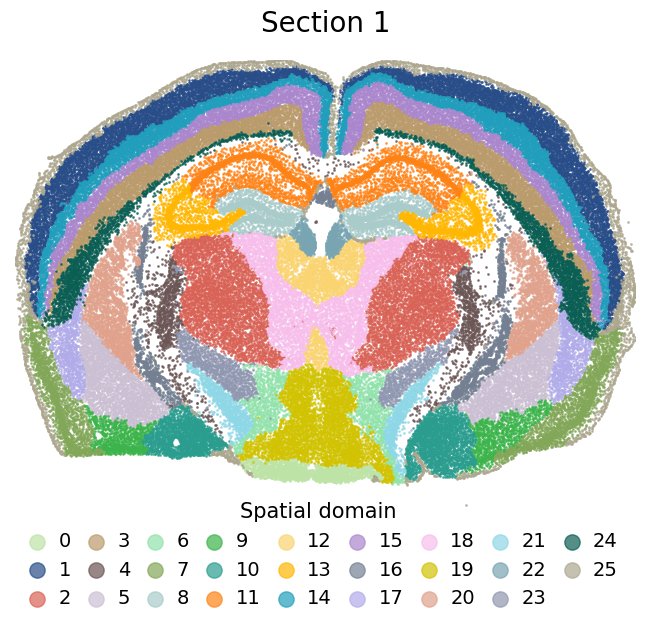

In [2]:
# Fig. 4b
K_DOMAIN = 26
COLORS = ['#BEE3A6', '#284d88', '#d96256', '#BA9B6C', '#6B5555', '#cbc0d3', '#91e2ab',
          '#83A759', '#A9CBCA', '#3cb44b', '#2A9D8F', '#FE8317', '#FAD471', '#ffb703',
          '#219ebc', '#AA87CD', '#748092', '#b1ace9', '#F7BEEC', '#D1C301', '#E0A28C',
          '#8ed7e6', '#79a5b2', '#9097b0', '#0B5E53', '#ADA78F']

svc_graph = load_npz(HERE / 'precomputed/adjacency_matrix_SVC.npz')
spatial_graph = load_npz(HERE / 'precomputed/adjacency_matrix_spatial.npz')
labels = spatial_domains(svc_graph, spatial_graph, K_DOMAIN)
labels_rep1, labels_rep2 = labels[:len(location_rep1)], labels[len(location_rep1):]
print('cells %d | domains %d | unassigned %d' % (len(labels), K_DOMAIN, (labels == -1).sum()))

fig, ax = plt.subplots(figsize=(8, 6))
for domain in range(K_DOMAIN):
    keep = labels_rep1 == domain
    ax.scatter(location_rep1[keep, 0], location_rep1[keep, 1], s=1, alpha=0.7,
               c=COLORS[domain], label=str(domain))

ax.set_title('Section 1', fontsize=20, pad=20)
ax.set_xlim(location_rep1[:, 0].min(), location_rep1[:, 0].max())
ax.set_ylim(location_rep1[:, 1].min(), location_rep1[:, 1].max())
ax.axis('off')

legend = ax.legend(title='Spatial domain', loc='upper right', bbox_to_anchor=(1, 0.08),
                   markerscale=11, fontsize=14, frameon=False, ncols=9,
                   title_fontsize=16, columnspacing=0.3, handletextpad=0.1)
plt.setp(legend.get_title(), fontsize=15)

plt.show()

## Fig. 4c — mean expression (log1p-transformed) of eight marker genes in each spatial domain

The solid arrow indicates the highest value.

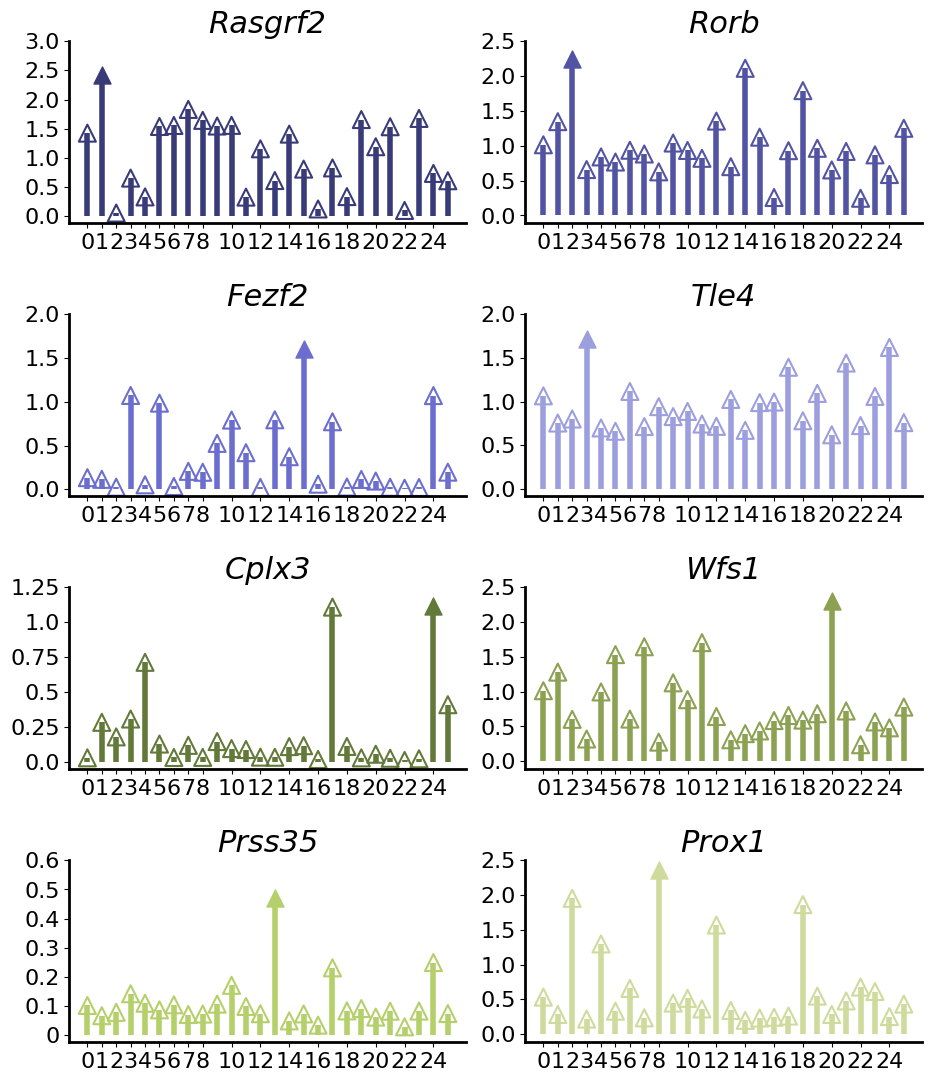

In [3]:
# Fig. 4c
import warnings
with warnings.catch_warnings():                  # scanpy re-exports deprecated anndata readers
    warnings.simplefilter('ignore', FutureWarning)
    import scanpy as sc

MARKERS = ['Rasgrf2', 'Rorb', 'Fezf2', 'Tle4', 'Cplx3', 'Wfs1', 'Prss35', 'Prox1']
XTICKS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 14, 16, 18, 20, 22, 24]

expression = []
for rep in ['rep1', 'rep2']:
    counts = sc.read_10x_h5(DATA_DIR / f'cell_feature_matrix_{rep}.h5')
    names = np.loadtxt(DATA_DIR / f'cell_names_{rep}.txt', dtype=str)
    row = {c: i for i, c in enumerate(counts.obs.index)}
    column = [list(counts.var.index).index(g) for g in MARKERS]
    expression.append(np.asarray(counts.X[:, column][[row[c] for c in names]].todense()))
expression = np.vstack(expression)

mean_log1p = np.array([[np.log1p(expression[labels == d, j]).mean() for d in range(K_DOMAIN)]
                       for j in range(len(MARKERS))])

palette = [plt.get_cmap('tab20b')(i) for i in range(len(MARKERS))]
fig, ax = plt.subplots(4, 2, figsize=(11, 13), gridspec_kw={'wspace': 0.15, 'hspace': 0.5})
x = np.arange(K_DOMAIN)
for k, (gene, color, a) in enumerate(zip(MARKERS, palette, ax.ravel())):
    height = mean_log1p[k]
    peak = np.argsort(height)[::-1][:1]
    rest = np.argsort(height)[::-1][1:]
    a.vlines(x=x, ymin=0, ymax=height, colors=color, linewidth=4)
    a.scatter(x[rest], height[rest], edgecolor=color, s=150, marker='^',
              facecolor='none', linewidth=1.5)
    a.scatter(x[peak], height[peak], color=color, s=150, marker='^')
    a.set_xticks(XTICKS); a.set_xticklabels(XTICKS, fontsize=16)
    # the automatic ticks are kept as they come -- Cplx3's are 0.25 apart and rounding them to one
    # decimal would move them. Prss35 is the one panel an order of magnitude smaller than the rest,
    # and its automatic ticks are set by hand.
    ticks = ([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6] if gene == 'Prss35'
             else [t for t in a.get_yticks() if t >= 0])
    a.set_yticks(ticks); a.set_yticklabels(ticks, fontsize=16)
    a.set_title(gene, fontsize=22, fontstyle='italic')
    a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)
    a.spines['left'].set_linewidth(2); a.spines['bottom'].set_linewidth(2)

plt.show()

## Fig. 4d — gene co-localization scores of cell-type-specific gene pairs across ten cell types

For each cell type, the pair shown is the one whose score most exceeds its average across cell
types. Grey indicates pairs detected in fewer than 20 cells of that cell type.

CA1-ProS     Slc17a7-Wfs1           0.770
CA2-IG-FC    Bhlhe22-Slc17a7        0.768
CA3          Cpne6-Slc17a7          0.963
DG           Epha4-Prox1            0.712
Sst          Dner-Gad1              0.848
Endo         Cldn5-Pglyrp1          0.840
Meis2        Meis2-Wfs1             0.829
Astro        Id2-Ntsr2              0.798
Oligo        Dpy19l1-Zfp536         0.716
Micro-PVM    Kctd12-Trem2           0.952


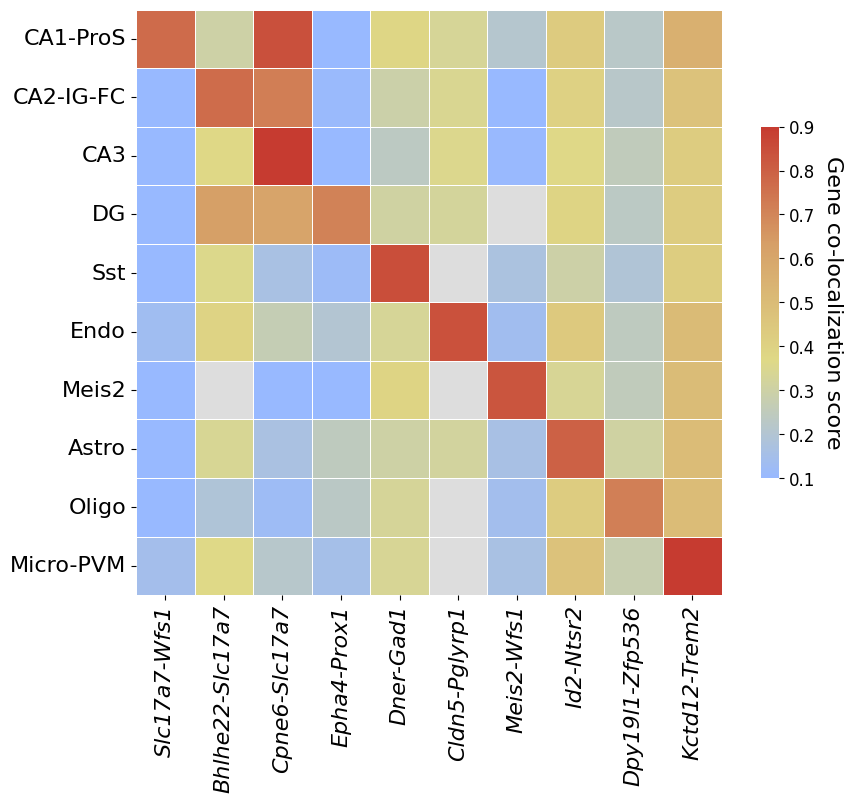

In [4]:
# Fig. 4d
import warnings

import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

MIN_CELLS = 20
CELL_TYPES = ['CA1-ProS', 'CA2-IG-FC', 'CA3', 'DG', 'Sst',
              'Endo', 'Meis2', 'Astro', 'Oligo', 'Micro-PVM']

_c = np.load(HERE / 'precomputed/coloc_multi.npz', allow_pickle=True)
score, detected, types = _c['score_fine'], _c['fine_valid'], list(_c['fine_types'])
gene_names = list(_c['gene_names'])
n_genes = len(gene_names)

eligible = detected >= MIN_CELLS
ia, ib = np.triu_indices(n_genes, 1)
pair_score = score[:, ia, ib]                                  # (type, pair)
pair_ok = eligible[:, ia] & eligible[:, ib]
with warnings.catch_warnings():           # a pair eligible in no type averages over nothing
    warnings.simplefilter('ignore', RuntimeWarning)
    pair_mean = np.nanmean(np.where(pair_ok, pair_score, np.nan), 0)

# each type's pair is the one whose score stands highest above the pair's own cross-type mean
chosen = []
for name in CELL_TYPES:
    t = types.index(name)
    specificity = np.where(pair_ok[t], pair_score[t] - pair_mean, -9)
    chosen.append((name, t, int(np.argmax(specificity))))

pair_labels = ['%s-%s' % (gene_names[ia[k]], gene_names[ib[k]]) for _, _, k in chosen]
grid = np.full((len(chosen), len(chosen)), np.nan)
for r, (_, t, _) in enumerate(chosen):
    for c, (_, _, k) in enumerate(chosen):
        i, j = ia[k], ib[k]
        if eligible[t, i] and eligible[t, j]:
            grid[r, c] = score[t, i, j]

cmap = LinearSegmentedColormap.from_list('coloc', ['#98B9FF', '#DFD987', '#D69F67', '#C63B30'])
cmap.set_bad('#dddddd')
fig, ax = plt.subplots(figsize=(9.5, 8))
hm = sns.heatmap(grid, cmap=cmap, vmin=0.1, vmax=0.9, ax=ax, linewidths=.5, linecolor='white',
                 square=True, xticklabels=pair_labels, yticklabels=[c[0] for c in chosen],
                 cbar_kws={'label': 'Gene co-localization score', 'shrink': .6})
cbar = hm.collections[0].colorbar
cbar.set_label('Gene co-localization score', fontsize=16, rotation=270, labelpad=20)
cbar.ax.tick_params(labelsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=16, fontstyle='italic')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=16)

for (name, t, k), label in zip(chosen, pair_labels):
    print('%-12s %-22s %.3f' % (name, label, score[t, ia[k], ib[k]]))

fig.tight_layout()
plt.show()

## Fig. 4e — first two principal components of the SVC gene-level latent representation in VLMCs against three measured descriptors: relative distance to the nuclear center, gyration and polarity

Solid lines mark |r| >= 0.30 and dashed lines indicate |r| < 0.30.

91 genes | PC1 17.8%  PC2 12.0%  PC3 6.5% of the variance


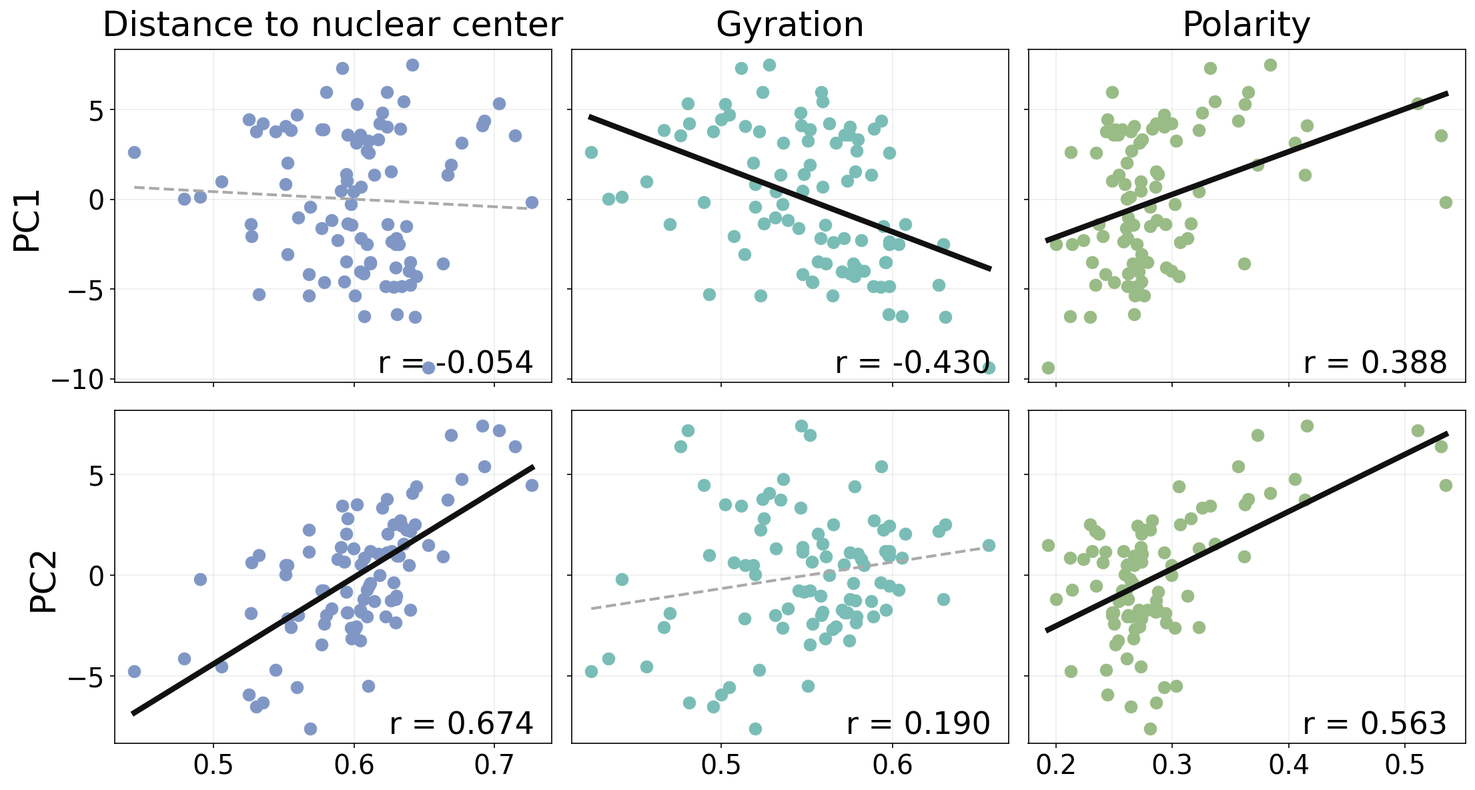

In [5]:
# Fig. 4e
from scipy.stats import pearsonr, spearmanr

DESCRIPTORS = [('distnuc', 'Distance to nuclear center'),
               ('gyration', 'Gyration'),
               ('polarity', 'Polarity')]
DESC_COLORS = ['#8097C6', '#79BDB6', '#99BB85']
STRONG = 0.30                     # |r| at or above this is drawn as a solid line

_v = np.load(HERE / 'precomputed/vlmc_gene_pca.npz', allow_pickle=True)
embedding = _v['embedding'].astype(np.float64)
measured = {key: _v[key] for key, _ in DESCRIPTORS}

# sampling depth and total signal each inflate the apparent spread, and controlling for one leaves
# the other free, so both are regressed out of every gene's embedding before the decomposition
covariates = np.column_stack([np.ones(len(embedding)),
                              np.log(_v['med_count']), np.log(_v['tot_count'])])
residual = embedding - covariates @ np.linalg.lstsq(covariates, embedding, rcond=None)[0]
U, S, _ = np.linalg.svd(residual - residual.mean(0), full_matrices=False)
component = U[:, :2] * S[:2]
# the sign of an SVD component is arbitrary; orient PC1 so that compact genes score high and PC2
# so that genes far from the nucleus do
if spearmanr(component[:, 0], measured['gyration'])[0] > 0:
    component[:, 0] *= -1
if spearmanr(component[:, 1], measured['distnuc'])[0] < 0:
    component[:, 1] *= -1
print('%d genes | PC1 %.1f%%  PC2 %.1f%%  PC3 %.1f%% of the variance'
      % (len(embedding), *(100 * S[:3] ** 2 / (S ** 2).sum())))

# rows share a component and columns share a descriptor, so only the outer ticks are labelled
fig, ax = plt.subplots(2, 3, figsize=(16.5 * 0.9, 8), sharex='col', sharey='row')
for i in range(2):
    for j, (key, label) in enumerate(DESCRIPTORS):
        a = ax[i, j]
        x, y = measured[key], component[:, i]
        r = pearsonr(x, y)[0]                    # Pearson, to match the least-squares line drawn
        strong = abs(r) >= STRONG
        a.scatter(x, y, s=80, c=DESC_COLORS[j], linewidth=.45, zorder=3)
        fit = np.polyfit(x, y, 1)
        grid = np.linspace(x.min(), x.max(), 50)
        a.plot(grid, np.polyval(fit, grid), color='#111' if strong else '#aaa',
               lw=4 if strong else 2, ls='-' if strong else '--', zorder=4)
        # right-aligned so the label stays inside the axes whatever the panel width is
        a.text(.96, .1, 'r = %.3f' % r, transform=a.transAxes, fontsize=22,
               ha='right', va='top')
        a.tick_params(axis='both', which='major', labelsize=19)
        a.grid(alpha=.22)
        if i == 0:
            a.set_title(label, fontsize=25, pad=10)
        if j == 0:
            a.set_ylabel('PC%d' % (i + 1), fontsize=25)

fig.tight_layout()
plt.show()

## Fig. 4f — distributions of PC1 and PC2 scores for genes grouped by protein targeting class

Classes are transmembrane, secretory/GPI-anchored and intracellular. P values from two-sided
Mann-Whitney U tests, one versus rest.

PC1  Transmembrane vs the rest   Mann-Whitney p = 0.0084  **
PC2  Intracellular vs the rest   Mann-Whitney p = 0.0095  **


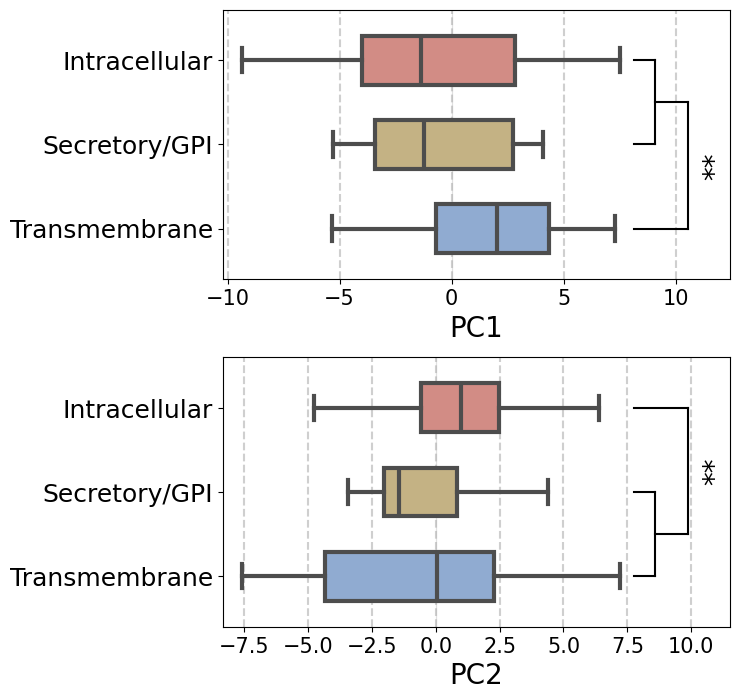

In [6]:
# Fig. 4f
from scipy.stats import mannwhitneyu

CLASSES = ['Intracellular', 'Secretory/GPI', 'Transmembrane']
CLASS_COLORS = {'Intracellular': '#D28C85', 'Secretory/GPI': '#C4B284',
                'Transmembrane': '#90ABD1'}
# the one cut that is significant on each axis, marked one-versus-the-other-two
FOCAL = {'PC1': 'Transmembrane', 'PC2': 'Intracellular'}
EDGE, EDGE_LW = '0.30', 3

targeting = pd.read_csv(HERE / 'precomputed/vlmc_protein_targeting.csv', keep_default_na=False)
assert list(targeting.gene) == list(_v['genes'].astype(str)), 'gene order must match Fig. 4e'
score = pd.DataFrame({'PC1': component[:, 0], 'PC2': component[:, 1],
                      'targeting': targeting.targeting.values})
score = score[score.targeting != 'OTHER']          # OTHER is only "no usable annotation"
row = {name: len(CLASSES) - 1 - i for i, name in enumerate(CLASSES)}   # first class on top

fig, ax = plt.subplots(2, 1, figsize=(7.5, 7.4))
for a, pc in zip(ax, ['PC1', 'PC2']):
    for name in CLASSES:
        line = dict(color=EDGE, linewidth=EDGE_LW)
        box = a.boxplot([score[pc][score.targeting == name].values], positions=[row[name]],
                        widths=.58, vert=False, patch_artist=True, showfliers=False, zorder=10,
                        boxprops=dict(edgecolor=EDGE, linewidth=EDGE_LW), medianprops=line,
                        whiskerprops=line, capprops=line)
        box['boxes'][0].set_facecolor(CLASS_COLORS[name])
    a.axvline(0, color='0.88', lw=.9, zorder=0)
    a.tick_params(axis='x', labelsize=15)
    a.set_yticks([row[c] for c in CLASSES]); a.set_yticklabels(CLASSES, fontsize=18)
    a.set_ylim(-.6, len(CLASSES) - .4)
    a.set_xlabel(pc, fontsize=20)
    a.grid(alpha=.6, axis='x', linestyle='--', linewidth=1.5, zorder=0)

# the p on the figure is the plain Mann-Whitney, so that the stars and the boxes come from the
# same numbers: nothing is regressed out of the scores that are drawn
stars = lambda p: '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'n.s.'
for a, pc in zip(ax, ['PC1', 'PC2']):
    focal = FOCAL[pc]
    is_focal = score.targeting == focal
    p = mannwhitneyu(score[pc][is_focal], score[pc][~is_focal])[1]

    left, right = a.get_xlim(); width = right - left
    inner, outer = right + .04 * width, right + .12 * width
    others = [row[c] for c in CLASSES if c != focal]
    middle, target = float(np.mean(others)), row[focal]
    line = dict(c='black', lw=1.5, clip_on=False, zorder=20)
    a.plot([inner, inner], [min(others), max(others)], **line)      # join the two other classes
    for y in others:
        a.plot([right - .01 * width, inner], [y, y], **line)
    a.plot([inner, outer], [middle, middle], **line)                # and carry that across
    a.plot([outer, outer], [middle, target], **line)                # to the focal class
    a.plot([right - .01 * width, outer], [target, target], **line)
    a.text(outer + .03 * width, (middle + target) / 2, stars(p), ha='left', va='center',
           fontsize=20, rotation=90)
    a.set_xlim(left, right + .22 * width)
    print('%s  %s vs the rest   Mann-Whitney p = %.4f  %s' % (pc, focal, p, stars(p)))

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Fig. 4g — mean per-cell cosine similarity between SVC latent representations of six oligodendrocyte-lineage genes, and observed transcript positions in six representative oligodendrocytes

The first three genes constitute the OPC-associated module (Pdgfra, Cspg4, Gpr17), the latter
three the maturation-associated module (Clmn, Zfp536, Prox1); the heatmap is computed across
oligodendrocytes in which all six genes were detected.

1101 oligodendrocytes detect all six | within-OPC 0.627  within-myelin 0.376  cross 0.259


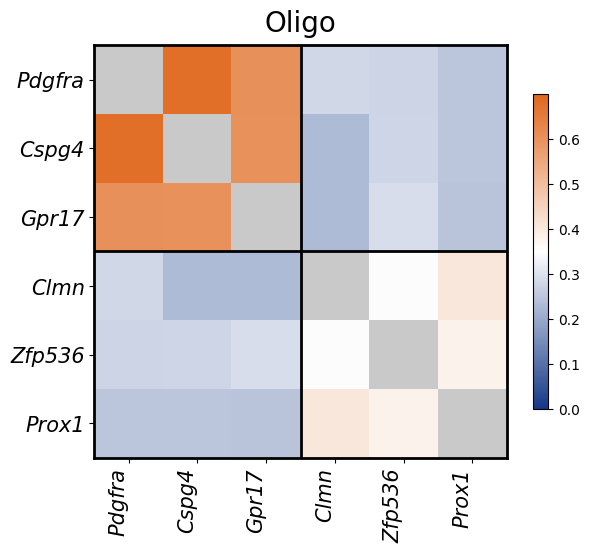

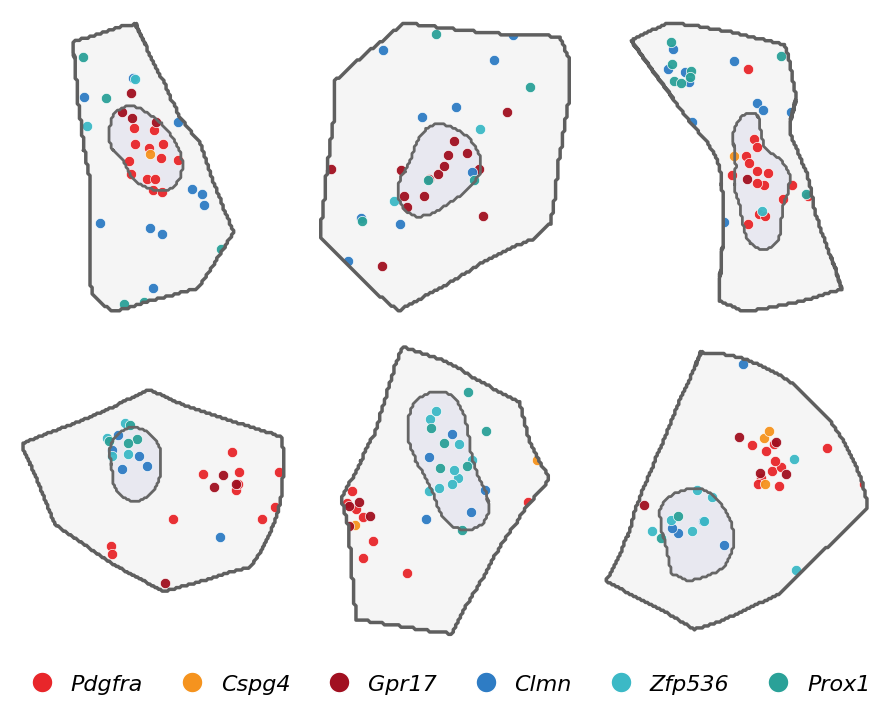

In [7]:
# Fig. 4g
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon

MODULE_COLORS = {'Pdgfra': '#E8262A', 'Cspg4': '#F5931E', 'Gpr17': '#A11020',
                 'Clmn': '#2E7CC4', 'Zfp536': '#3CB9C6', 'Prox1': '#2AA198'}

_o = np.load(HERE / 'precomputed/oligo_modules.npz', allow_pickle=True)
module_genes = list(_o['genes'].astype(str))
opc, myelin = [0, 1, 2], [3, 4, 5]

### the two modules in the SVC latent

mean_cosine = _o['cosine'].mean(0)
block = lambda a, b: np.mean([mean_cosine[i, j] for i in a for j in b if i != j])
print('%d oligodendrocytes detect all six | within-OPC %.3f  within-myelin %.3f  cross %.3f'
      % (len(_o['cosine']), block(opc, opc), block(myelin, myelin), block(opc, myelin)))

grid = mean_cosine.copy()
np.fill_diagonal(grid, np.nan)              # a gene's cosine with itself is 1 and carries nothing
coloc_cmap = LinearSegmentedColormap.from_list('coloc6', ['#143887', 'white', '#E0671B'])
coloc_cmap.set_bad('#c9c9c9')

fig, ax = plt.subplots(figsize=(6.3, 5.6))
im = ax.imshow(grid, cmap=coloc_cmap, norm=TwoSlopeNorm(vmin=0, vcenter=0.35, vmax=0.7))
ax.set_xticks(range(len(module_genes))); ax.set_yticks(range(len(module_genes)))
ax.set_xticklabels(module_genes, rotation=90, ha='right')
ax.set_yticklabels(module_genes)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontsize(15); label.set_fontstyle('italic')
ax.axhline(2.5, color='k', lw=2); ax.axvline(2.5, color='k', lw=2)   # the module boundary
ax.set_title('Oligo', fontsize=20, pad=10)
for spine in ax.spines.values():
    spine.set_linewidth(2)
fig.colorbar(im, shrink=0.7)
fig.tight_layout()
plt.show()

### six matched cells, three with each module in the nucleus

span = lambda key, i: slice(_o[f'{key}_pointer'][i], _o[f'{key}_pointer'][i + 1])

fig, axes = plt.subplots(2, 3, figsize=(9, 7.2))
for i, a in enumerate(axes.ravel()):
    outline = _o['cell_points'][span('cell', i)]
    clip = Polygon(outline, closed=True, transform=a.transData)      # dots stay inside the cell
    a.fill(*outline.T, color='#f5f5f5', zorder=0)
    nucleus = _o['nucleus_points'][span('nucleus', i)]
    a.fill(*nucleus.T, color='#e8e8f0', zorder=1)

    s = span('tx', i)
    dx, dy, gene = _o['tx_dx'][s], _o['tx_dy'][s], _o['tx_gene'][s]
    for k, name in enumerate(module_genes):
        on = gene == k
        dots = a.scatter(dx[on], dy[on], s=55, color=MODULE_COLORS[name], alpha=0.95,
                         edgecolor='white', linewidth=0.5, zorder=5)
        dots.set_clip_path(clip)

    a.plot(*nucleus.T, '-', color='#666', lw=2, zorder=6)             # boundaries above the dots
    a.plot(*outline.T, '-', color='#5F5F5F', lw=2.5, zorder=6)
    a.set_aspect('equal'); a.axis('off')

legend = fig.legend(handles=[Line2D([0], [0], marker='o', color='w', markersize=15,
                                    markerfacecolor=MODULE_COLORS[g], markeredgecolor='white',
                                    label=g) for g in module_genes],
                    loc='lower center', ncol=6, fontsize=16, frameon=False,
                    bbox_to_anchor=(0.5, 0.0), handletextpad=0.3, columnspacing=1.2)
for text in legend.get_texts():
    text.set_fontstyle('italic')
fig.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()

## Fig. 4h — per-cell difference in relative distance to the nuclear center between the two modules, stratified by Opalin expression level, and each module's mean distance across Opalin levels

Right panel: cells are stratified by quartiles of the corresponding module transcript count;
error bars indicate the standard error of the mean.

n=1101 | Spearman of (myelin - OPC) against Opalin = -0.588


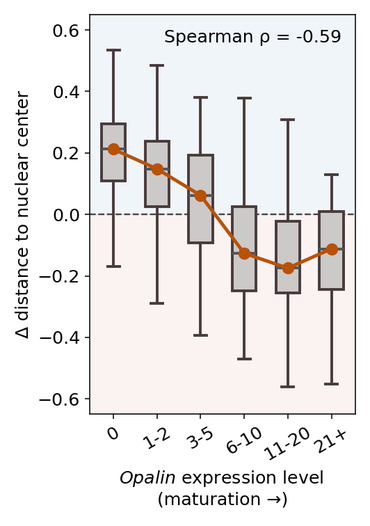

opc      partial Spearman against Opalin at fixed count = +0.19
mye      partial Spearman against Opalin at fixed count = -0.52


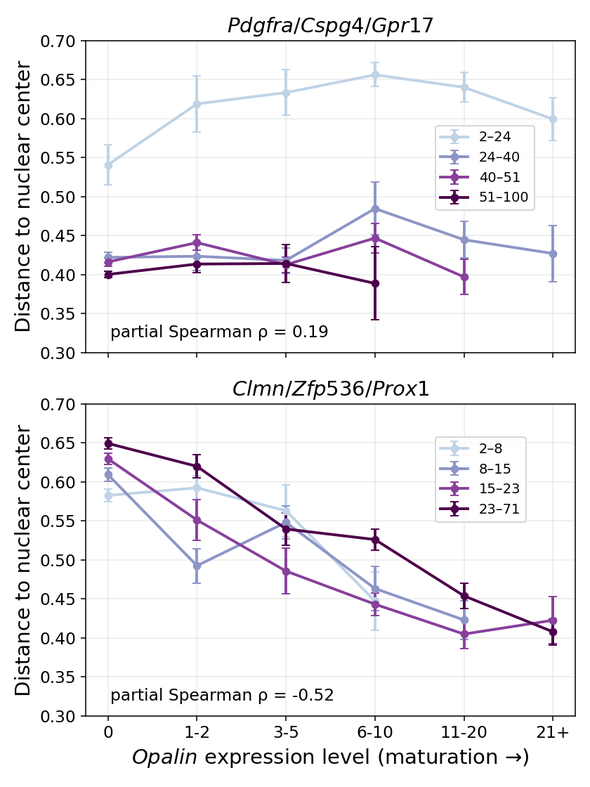

In [8]:
# Fig. 4h
from scipy.stats import rankdata, spearmanr

LEVELS = ['0', '1-2', '3-5', '6-10', '11-20', '21+']
EDGES = [-.1, 0, 2, 5, 10, 20, 1e4]
BOX, BOX_EDGE, MEDIAN_LINE = '#ccc9c9', '#493b3b', '#B85209'
MIN_IN_BIN, N_COUNT_BINS = 8, 4

maturation = pd.read_csv(HERE / 'precomputed/oligo_maturation.csv')
maturation['level'] = pd.cut(maturation.opal, EDGES, labels=LEVELS)
rho = spearmanr(maturation.d, maturation.opal)[0]
print('n=%d | Spearman of (myelin - OPC) against Opalin = %+.3f' % (len(maturation), rho))

### the per-cell difference along maturation

per_level = [maturation.d[maturation.level == l].values for l in LEVELS]
low, high = -0.65, 0.65

fig, ax = plt.subplots(figsize=(3.8, 5.4))
ax.axhspan(0, high, color='#cfe0f0', alpha=0.30, zorder=0)      # myelin further out, immature
ax.axhspan(low, 0, color='#f3d4d4', alpha=0.30, zorder=0)       # OPC further out, mature
ax.boxplot(per_level, positions=range(len(LEVELS)), widths=0.55, patch_artist=True,
           showfliers=False, zorder=3,
           medianprops=dict(color='#555', lw=2),
           boxprops=dict(facecolor=BOX, edgecolor=BOX_EDGE, lw=2),
           whiskerprops=dict(color=BOX_EDGE, lw=2), capprops=dict(color=BOX_EDGE, lw=2))
ax.plot(range(len(LEVELS)), [np.median(v) for v in per_level], '-o', color=MEDIAN_LINE,
        ms=8, lw=2.5, zorder=5)
ax.axhline(0, color='#444', ls='--', lw=1.2)
ax.set_xticks(range(len(LEVELS))); ax.set_xticklabels(LEVELS, fontsize=13, rotation=30)
ax.tick_params(axis='y', labelsize=13)
ax.set_ylim(low, high); ax.set_xlim(-0.55, len(LEVELS) - 0.45)
ax.set_xlabel('$\\it{Opalin}$ expression level \n(maturation →)', fontsize=13)
ax.set_ylabel('Δ distance to nuclear center', fontsize=13)
ax.text(0.28, 0.93, 'Spearman ρ = %+.2f' % rho, transform=ax.transAxes, fontsize=13)

fig.tight_layout()
plt.show()

### each module on its own, with its transcript count held roughly fixed

def partial_spearman(y, x, control):
    """Spearman of y and x after the rank of `control` is regressed out of both"""
    design = np.column_stack([np.ones(len(y)), rankdata(control)])
    residual = lambda v: rankdata(v) - design @ np.linalg.lstsq(design, rankdata(v), rcond=None)[0]
    return np.corrcoef(residual(y), residual(x))[0, 1]

shade = plt.get_cmap('BuPu')
position = {l: i for i, l in enumerate(LEVELS)}
panels = [(r'$\it{Pdgfra}$/$\it{Cspg4}$/$\it{Gpr17}$', 'opc', 'opc_n'),
          (r'$\it{Clmn}$/$\it{Zfp536}$/$\it{Prox1}$', 'mye', 'mye_n')]

fig, ax = plt.subplots(2, 1, figsize=(6, 8), sharex=True)
for a, (title, column, count) in zip(ax, panels):
    maturation['count_bin'] = pd.qcut(maturation[count], N_COUNT_BINS, duplicates='drop')
    bins = list(maturation.count_bin.cat.categories)
    for k, edge in enumerate(bins):
        of_bin = maturation[maturation.count_bin == edge]
        x, y, err = [], [], []
        for level in LEVELS:
            cells = of_bin[of_bin.level == level]
            if len(cells) >= MIN_IN_BIN:
                x.append(position[level])
                y.append(cells[column].mean())
                err.append(cells[column].std() / np.sqrt(len(cells)))
        a.errorbar(x, y, yerr=err, marker='o', ms=5, lw=2, capsize=3,
                   color=shade(0.25 + 0.75 * k / (len(bins) - 1)),
                   label='%d–%d' % (max(int(edge.left), 0), int(edge.right)))
    partial = partial_spearman(maturation[column].values, maturation.opal.values,
                               maturation[count].values)
    a.set_title(title, fontsize=15, color='black')
    a.text(0.05, 0.05, 'partial Spearman ρ = %.2f' % partial, transform=a.transAxes,
           fontsize=12, color='black')
    a.set_xticks(range(len(LEVELS))); a.set_xticklabels(LEVELS)
    a.grid(alpha=0.25); a.tick_params(axis='both', labelsize=12)
    a.set_ylim(0.3, 0.7)
    a.set_ylabel('Distance to nuclear center', fontsize=15)
    print('%-8s partial Spearman against Opalin at fixed count = %+.2f' % (column, partial))

ax[1].set_xlabel('$\\it{Opalin}$ expression level (maturation →)', fontsize=15)
ax[0].legend(fontsize=10, frameon=True, bbox_to_anchor=(0.7, 0.75))
ax[1].legend(fontsize=10, frameon=True, bbox_to_anchor=(0.7, 0.6))
fig.tight_layout()
plt.show()

## Fig. 4i — predicted per-cell polarity of three unmeasured genes in VLMCs from the Xenium 5K section, and predicted transcript positions of Spp1 in four representative cells

Each gene is compared with a count-matched background constructed from other imputed genes by
resampling to match the target gene's per-cell transcript-count distribution. P values from
one-sided Mann-Whitney U tests with Benjamini-Hochberg correction across genes.

930 VLMC cells | eligible 24/84 | significant ['Acsbg1', 'Igfbp6', 'Cldn5', 'Spp1', 'Igfbp5']
  Acsbg1   count-matched FDR = 2.0e-07  (45 cells vs 90 background)
  Igfbp6   count-matched FDR = 1.3e-19  (275 cells vs 550 background)
  Cldn5    count-matched FDR = 2.0e-07  (135 cells vs 270 background)
  Spp1     count-matched FDR = 3.8e-22  (702 cells vs 1404 background)
  Igfbp5   count-matched FDR = 2.2e-05  (785 cells vs 1570 background)


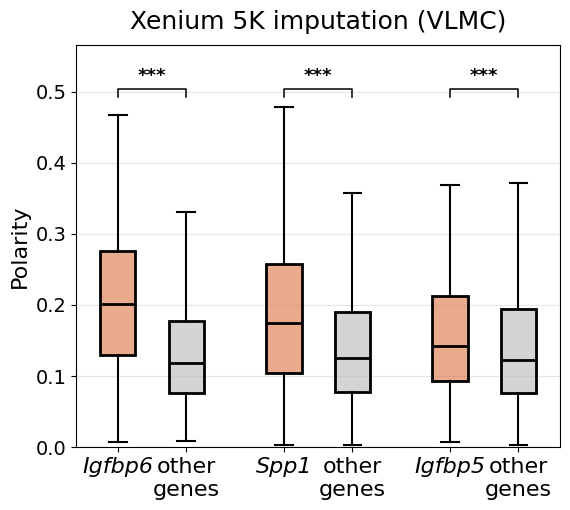

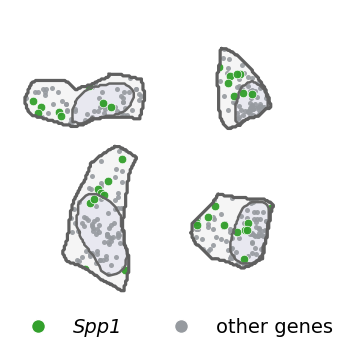

In [9]:
# Fig. 4i
from scipy.stats import mannwhitneyu
from matplotlib.colors import to_rgba

MIN_COUNTS, MIN_VALID_CELLS = 3, 20      # the 5K predictions are sparse, hence 3 rather than 5
N_COUNT_BINS, MATCH_SEED, FDR_SIG = 7, 0, 0.05
BACKGROUND_PER_CELL = 2                  # background cells drawn per cell of the gene, within a bin
SHOWN = ['Igfbp6', 'Spp1', 'Igfbp5']     # the secreted ECM genes among the significant set
GENE_C, BG_C, PAIR, STRIDE = '#DC7240', '0.72', 1.65, 4

_p = np.load(HERE / 'precomputed/vlmc_polarity.npz', allow_pickle=True)
imputed_genes = list(_p['genes'].astype(str))
polarity, counts = _p['polarity'], _p['counts']

def benjamini_hochberg(p):
    p = np.asarray(p, float)
    order = np.argsort(p)
    step = np.minimum.accumulate((p[order] * len(p) / np.arange(1, len(p) + 1))[::-1])[::-1]
    out = np.empty(len(p)); out[order] = np.minimum(step, 1)
    return out

def cells_of(j):
    """polarity and transcript count of gene j in its eligible cells"""
    enough = counts[:, j] >= MIN_COUNTS
    value, count = polarity[enough, j], counts[enough, j]
    finite = np.isfinite(value)
    return value[finite], count[finite]

def count_matched_background(count, bg_value, bg_count):
    """resample the background to match the target gene's per-cell transcript-count distribution."""
    rng = np.random.default_rng(MATCH_SEED)
    edges = np.unique(np.quantile(count, np.linspace(0, 1, N_COUNT_BINS + 1)))
    matched = []
    for k in range(len(edges) - 1):
        lo, hi = edges[k], edges[k + 1]
        top = hi if k < len(edges) - 2 else hi + 1e9        # the last bin has to include its edge
        want = int(((count >= lo) & (count < top)).sum()) * BACKGROUND_PER_CELL
        pool = bg_value[(bg_count >= lo) & (bg_count < top)]
        if want and len(pool):
            matched.append(rng.choice(pool, min(want, len(pool)), replace=len(pool) < want))
    return np.concatenate(matched) if matched else bg_value

eligible = [j for j in range(len(imputed_genes))
            if (counts[:, j] >= MIN_COUNTS).sum() >= MIN_VALID_CELLS]
trusted = {imputed_genes[j]: cells_of(j) for j in eligible}

tested, matched_p, matched_background = [], [], {}
for j in eligible:
    gene = imputed_genes[j]
    value, count = trusted[gene]
    others = [g for g in trusted if g != gene]
    background = count_matched_background(count,
                                          np.concatenate([trusted[g][0] for g in others]),
                                          np.concatenate([trusted[g][1] for g in others]))
    matched_background[gene] = background
    tested.append((gene, len(value), float(value.mean())))
    matched_p.append(mannwhitneyu(value, background, alternative='greater')[1])

fdr = dict(zip([t[0] for t in tested], benjamini_hochberg(matched_p)))
significant = sorted([g for g in fdr if fdr[g] < FDR_SIG],
                     key=lambda g: -dict((t[0], t[2]) for t in tested)[g])
print('%d VLMC cells | eligible %d/%d | significant %s'
      % (len(polarity), len(eligible), len(imputed_genes), significant))
for gene in significant:
    print('  %-8s count-matched FDR = %.1e  (%d cells vs %d background)'
          % (gene, fdr[gene], len(trusted[gene][0]), len(matched_background[gene])))

### each shown gene against its own count-matched background

stars = lambda q: '***' if q < 1e-3 else '**' if q < 1e-2 else '*' if q < FDR_SIG else 'n.s.'
data, colors, positions, labels = [], [], [], []
for k, gene in enumerate(SHOWN):
    data += [trusted[gene][0], matched_background[gene]]
    colors += [GENE_C, BG_C]
    positions += [k * STRIDE, k * STRIDE + PAIR]
    labels += [gene, 'other\ngenes']

fig, ax = plt.subplots(figsize=(5.8, 5.2))
# matplotlib's default 1.5-IQR whiskers with the outliers left undrawn: on these right-skewed
# distributions that hides a few per cent of the cells per box and keeps the panel's height
box = ax.boxplot(data, positions=positions, widths=0.85, showfliers=False, patch_artist=True,
                 whiskerprops=dict(color='k', lw=1.5), capprops=dict(color='k', lw=1.5),
                 medianprops=dict(color='k', lw=2))
for patch, color in zip(box['boxes'], colors):
    patch.set(facecolor=to_rgba(color, 0.6), edgecolor='k', linewidth=2)

cap = max(c.get_ydata().max() for c in box['caps'])       # the top of what is actually drawn
top = cap * 1.18
tick, bar = 0.02 * top, cap + 0.045 * top
for k, gene in enumerate(SHOWN):
    left, right = k * STRIDE, k * STRIDE + PAIR
    ax.plot([left, left, right, right], [bar - tick, bar, bar, bar - tick], color='k', lw=1.1)
    ax.text((left + right) / 2, bar + 0.008 * top, stars(fdr[gene]), ha='center', va='bottom',
            fontsize=13, fontweight='bold')

ax.set_xticks(positions); ax.set_xticklabels(labels, fontsize=16)
for text, label in zip(ax.get_xticklabels(), labels):
    if not label.startswith('other'):
        text.set_fontstyle('italic')
ax.tick_params(axis='y', labelsize=14)
ax.set_xlim(-1.0, (len(SHOWN) - 1) * STRIDE + PAIR + 1.0); ax.set_ylim(0, top)
ax.set_ylabel('Polarity', fontsize=16)
ax.set_title('Xenium 5K imputation (VLMC)', fontsize=18, y=1.02)
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
plt.show()

### four of those cells, Spp1 against the rest of the imputed panel

from matplotlib.lines import Line2D
from matplotlib.patches import Polygon

SPP1_C, AMBIENT_C = '#33A02C', '#969A9F'

_s = np.load(HERE / 'precomputed/vlmc_spp1_cells.npz', allow_pickle=True)
span = lambda key, i: slice(_s[f'{key}_pointer'][i], _s[f'{key}_pointer'][i + 1])
n_cells = len(_s['exemplar_cells'])
limit = 1.05 * max(np.hypot(*_s['cell_points'][span('cell', i)].T).max() for i in range(n_cells))

fig, axes = plt.subplots(2, 2, figsize=(4.5, 4))
for i, a in enumerate(axes.ravel()):
    outline = _s['cell_points'][span('cell', i)]
    clip = Polygon(outline, closed=True, transform=a.transData)
    a.fill(*outline.T, color='#f5f5f5', zorder=0)
    nucleus = _s['nucleus_points'][span('nucleus', i)]
    if len(nucleus):
        a.fill(*nucleus.T, color='#e8e8f0', zorder=1)

    ambient = _s['other_points'][span('other', i)]
    dots = a.scatter(*ambient.T, s=13, color=AMBIENT_C, alpha=.9, lw=0, zorder=3)
    dots.set_clip_path(clip)
    spp1 = _s['gene_points'][span('gene', i)]
    dots = a.scatter(*spp1.T, s=38, color=SPP1_C, alpha=.95, edgecolor='white', linewidth=.5,
                     zorder=5)
    dots.set_clip_path(clip)

    if len(nucleus):
        a.plot(*nucleus.T, '-', color='#666', lw=1.8, zorder=6)
    a.plot(*outline.T, '-', color='#5F5F5F', lw=2.3, zorder=6)
    a.set_xlim(-limit, limit); a.set_ylim(limit, -limit)
    a.set_aspect('equal'); a.axis('off')

fig.subplots_adjust(left=0.02, right=0.76, top=0.99, bottom=0.01, wspace=-0.2, hspace=-0.5)
marker = lambda c: Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                          markeredgecolor='white', markersize=10)
legend = fig.legend(handles=[marker(SPP1_C), marker(AMBIENT_C)], labels=['Spp1', 'other genes'],
                    loc='center left', ncol=2, fontsize=14, frameon=False,
                    bbox_to_anchor=(0., 0.1))
legend.get_texts()[0].set_fontstyle('italic')
plt.show()

## Fig. 4j — per-cell Earth Mover's Distance between the predicted subcellular distributions of each imputed gene pair in astrocytes and endothelial cells, and predicted transcript positions in four representative cells of each type

Each pair is compared with a count-matched background of the same gene paired with every other
imputed gene, resampled to match the pair's per-cell total transcript count. P values from
one-sided Mann-Whitney U tests with Benjamini-Hochberg correction across gene pairs. The scan is
run upstream; the notebook reads the two arrays in `precomputed/coloc_emd_5k.npz`.

  Endo   Cldn5     + Cobll1     Cliff d = +0.704  BH-FDR = 1.98e-06  (of 56 ordered pairs)
  Astro  Acsbg1    + Slc39a12   Cliff d = +0.727  BH-FDR = 1.35e-81  (of 342 ordered pairs)


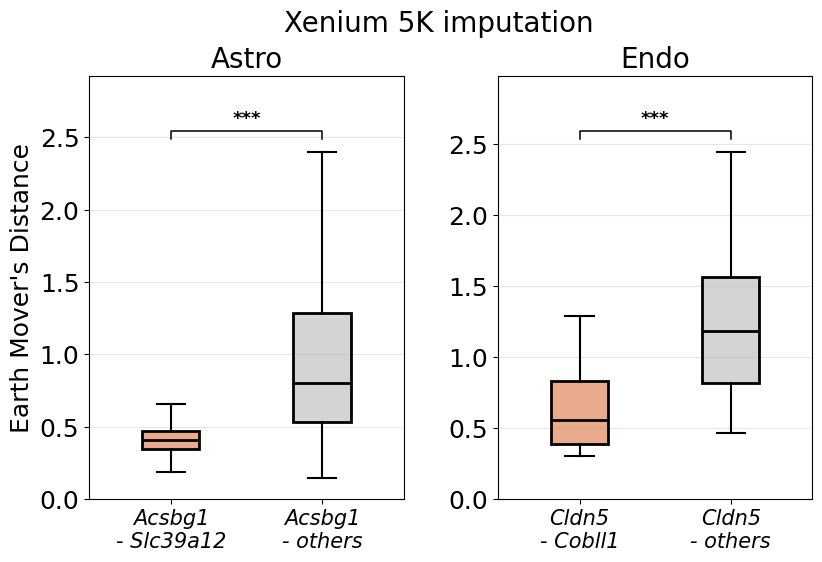

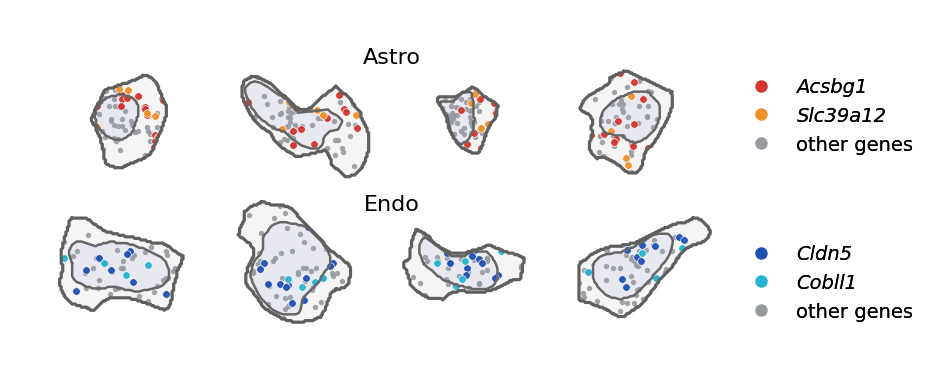

In [10]:
# Fig. 4j
EMD_PAIR_C, EMD_BG_C, EMD_PAIR, EMD_STRIDE = '#DC7240', '0.72', 1.85, 4.5

_e = np.load(HERE / 'precomputed/coloc_emd_5k.npz', allow_pickle=True)
emd_span = lambda key, i: slice(_e[f'{key}_pointer'][i], _e[f'{key}_pointer'][i + 1])
for k in range(len(_e['anchors'])):
    print('  %-6s %-9s + %-9s  Cliff d = %+.3f  BH-FDR = %.2e  (of %d ordered pairs)'
          % (_e['cell_types'][k], _e['anchors'][k], _e['partners'][k], _e['delta'][k],
             _e['fdr'][k], _e['n_pairs'][k]))

def draw_boxes(a, rows, title, with_ylabel):
    data, colors, positions, ticks, labels, bases = [], [], [], [], [], []
    for n, k in enumerate(rows):
        base = n * EMD_STRIDE
        data += [_e['pair_points'][emd_span('pair', k)],
                 _e['background_points'][emd_span('background', k)]]
        colors += [EMD_PAIR_C, EMD_BG_C]
        positions += [base, base + EMD_PAIR]; ticks += [base, base + EMD_PAIR]
        labels += ['%s\n- %s' % (_e['anchors'][k], _e['partners'][k]),
                   '%s\n- others' % _e['anchors'][k]]
        bases.append(base)

    box = a.boxplot(data, positions=positions, widths=0.7, showfliers=False, patch_artist=True,
                    whiskerprops=dict(color='k', lw=1.5), capprops=dict(color='k', lw=1.5),
                    medianprops=dict(color='k', lw=2))
    for patch, color in zip(box['boxes'], colors):
        patch.set(facecolor=to_rgba(color, 0.6), edgecolor='k', linewidth=2)

    cap = max(c.get_ydata().max() for c in box['caps'])
    top = cap * 1.22
    tick, bar = 0.02 * top, cap + 0.05 * top
    for n, k in enumerate(rows):
        left, right = bases[n], bases[n] + EMD_PAIR
        a.plot([left, left, right, right], [bar - tick, bar, bar, bar - tick], color='k', lw=1.1)
        a.text((left + right) / 2, bar + 0.008 * top, stars(_e['fdr'][k]), ha='center',
               va='bottom', fontsize=13, fontweight='bold')

    a.set_xticks(ticks); a.set_xticklabels(labels, fontsize=15, fontstyle='italic')
    a.tick_params(axis='y', labelsize=18)
    a.set_xlim(-1.0, bases[-1] + EMD_PAIR + 1.0); a.set_ylim(0, top)
    if with_ylabel:
        a.set_ylabel("Earth Mover's Distance", fontsize=18)
    a.set_title(title, fontsize=20); a.grid(axis='y', alpha=0.3)

fig, ax = plt.subplots(1, 2, figsize=(14 * 2 / 3, 5.5), gridspec_kw={'wspace': 0.3})
for a, name, with_ylabel in [(ax[0], 'Astro', True), (ax[1], 'Endo', False)]:
    draw_boxes(a, [k for k in range(len(_e['anchors'])) if _e['cell_types'][k] == name],
               name, with_ylabel)
fig.suptitle('Xenium 5K imputation', fontsize=20, y=1)
with warnings.catch_warnings():          # matplotlib reports that it cannot lay these two axes out
    warnings.simplefilter('ignore', UserWarning)   # and then produces the intended figure anyway
    fig.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

### eight of those cells, the pair against the rest of the imputed panel

PAIR_COLORS = {'Astro': ['#d1362f', '#f0902a'], 'Endo': ['#1f4fb0', '#26b3d1']}

_x = np.load(HERE / 'precomputed/coloc_exemplar_cells.npz', allow_pickle=True)
span = lambda key, i: slice(_x[f'{key}_pointer'][i], _x[f'{key}_pointer'][i + 1])
types = list(_x['exemplar_types'].astype(str))
pair_genes = dict(zip(['Astro', 'Endo'], _x['pair_genes'].astype(str)))
limit = 1.2 * max(np.hypot(*_x['cell_points'][span('cell', i)].T).max()
                  for i in range(len(types)))

fig, axes = plt.subplots(2, 4, figsize=(14, 3.8))
for i, a in enumerate(axes.ravel()):
    outline = _x['cell_points'][span('cell', i)]
    clip = Polygon(outline, closed=True, transform=a.transData)
    a.fill(*outline.T, color='#f5f5f5', zorder=0)
    nucleus = _x['nucleus_points'][span('nucleus', i)]
    if len(nucleus):
        a.fill(*nucleus.T, color='#e8e8f0', zorder=1)

    dots = a.scatter(*_x['other_points'][span('other', i)].T, s=15, color=AMBIENT_C,
                     alpha=.9, lw=0, zorder=3)
    dots.set_clip_path(clip)
    for key, color in zip(('first', 'second'), PAIR_COLORS[types[i]]):
        dots = a.scatter(*_x[f'{key}_points'][span(key, i)].T, s=30, color=color, alpha=.95,
                         edgecolor='white', linewidth=.5, zorder=5)
        dots.set_clip_path(clip)

    if len(nucleus):
        a.plot(*nucleus.T, '-', color='#666', lw=1.8, zorder=6)
    a.plot(*outline.T, '-', color='#5F5F5F', lw=2.3, zorder=6)
    a.set_xlim(-limit, limit); a.set_ylim(limit, -limit)
    a.set_aspect('equal'); a.axis('off')

# Each row's label sits the same distance above that row's tallest cell. Anchoring on the axes
# boxes instead would put the two labels at different heights above their cells, because the boxes
# overlap (negative hspace) and each cell fills a different fraction of its own box.
LABEL_GAP = 0.05                         # figure fraction, cell top to label baseline
fig.canvas.draw()
for row, name in enumerate(['Astro', 'Endo']):
    boxes = [a.get_position() for a in axes[row]]
    tops = []
    for column, box in enumerate(boxes):
        # y runs downward in these axes, so the topmost drawn point is the smallest y
        highest = _x['cell_points'][span('cell', row * len(boxes) + column)][:, 1].min()
        tops.append(box.y0 + box.height * (highest - limit) / (-2 * limit))
    fig.text((min(b.x0 for b in boxes) + max(b.x1 for b in boxes)) / 2,
             max(tops) + LABEL_GAP, name, fontsize=16, ha='center', va='bottom')

fig.subplots_adjust(left=0.01, right=0.99, top=0.98, bottom=0.02, hspace=-0.3, wspace=-0.8)
for name, y in [('Astro', 0.70), ('Endo', 0.26)]:
    handles = [marker(c) for c in PAIR_COLORS[name]] + [marker(AMBIENT_C)]
    legend = fig.legend(handles=handles, labels=list(pair_genes[name]) + ['other genes'],
                        loc='center left', ncol=1, fontsize=14, frameon=False,
                        bbox_to_anchor=(0.75, y))
    for text in legend.get_texts()[:2]:
        text.set_fontstyle('italic')
    fig.add_artist(legend)

plt.show()

## Fig. 4k — predicted relative distance to the nuclear center of one imputed gene in Micro-PVM cells and in astrocytes, from wild-type (WT) and P301S tau-transgenic (tau Tg) sections

P values from two-sided Mann-Whitney U tests with Benjamini-Hochberg correction across genes
within each cell type. Lower panels show the difference in the SVC-predicted subcellular
distributions between tau Tg and WT cells, averaged over cells as the per-pixel change in mass
fraction; each cell's map is normalized to sum to one before averaging.

Micro-PVM   5 of 84 genes eligible | the 84 pooled move +0.00378, p = 3.5e-02
    Laptm5   +0.01314  FDR = 4.1e-04  n = (132, 315)  3.5x the pooled shift | male cohort +0.01768, p = 5.3e-07
    Kctd12   +0.01763  FDR = 4.0e-03  n = (37, 113)  4.7x the pooled shift | male cohort +0.00629, p = 2.4e-01
Astro      11 of 84 genes eligible | the 84 pooled move -0.00149, p = 4.8e-03
    Clmn     -0.00979  FDR = 4.6e-04  n = (298, 384)  6.6x the pooled shift | male cohort +0.00490, p = 1.8e-01


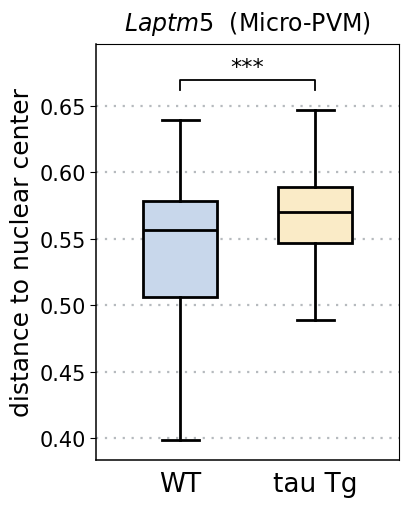

Laptm5   in Micro-PVM  | WT n = 132 median 0.5568 | tau Tg n = 315 median 0.5699 | +0.01314  p = 8.21e-05  FDR = 4.1e-04 (***)  AUC = 0.618


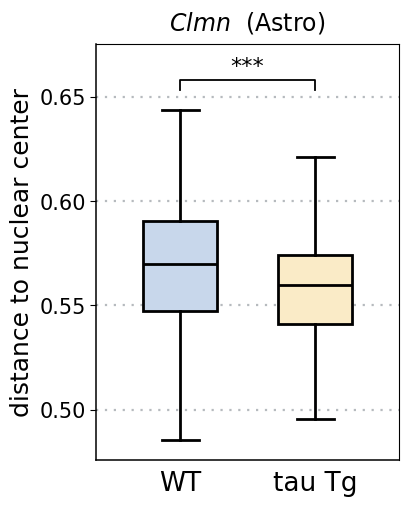

Clmn     in Astro      | WT n = 298 median 0.5698 | tau Tg n = 384 median 0.5600 | -0.00979  p = 4.15e-05  FDR = 4.6e-04 (***)  AUC = 0.409


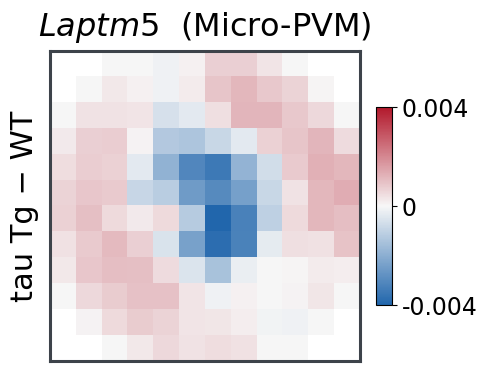

Laptm5   largest pixel 0.00414, colour capped at 0.004 | shells inner to outer -0.0109  -0.0189  -0.0163  +0.0088  +0.0180  +0.0192


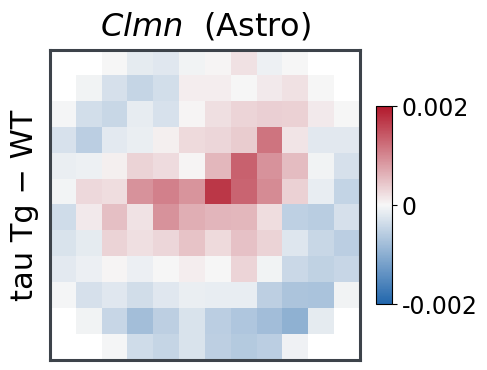

Clmn     largest pixel 0.00171, colour capped at 0.002 | shells inner to outer +0.0038  +0.0051  +0.0077  +0.0018  -0.0053  -0.0132


In [11]:
# Fig. 4k
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

MIN_VALID_CELLS = 20                            # per genotype, for a gene to enter the screen
BOX_FILL = ['#C8D7EB', '#FAEBC7']               # wild type, tau transgenic
COLOR_CAP = {'Laptm5': 0.004, 'Clmn': 0.002}

_t = np.load(HERE / 'precomputed/tau_localization.npz', allow_pickle=True)
tau_genes = list(_t['genes'].astype(str))

BACKGROUND_PIXELS = [(0, 0), (0, 1), (0, 10), (0, 11), (1, 0), (1, 11),
                     (10, 0), (10, 11), (11, 0), (11, 1), (11, 10), (11, 11)]
_keep = np.ones((12, 12), bool)
for _r, _c in BACKGROUND_PIXELS:
    _keep[_r, _c] = False
tau_foreground = _keep.ravel()
_ii, _jj = np.meshgrid(np.arange(12), np.arange(12), indexing='ij')
tau_x, tau_y = (_jj + 0.5 - 6).ravel() / 6, (_ii + 0.5 - 6).ravel() / 6
tau_radius = np.hypot(tau_x, tau_y)

### every imputed gene, in each of the two glial populations

def benjamini_hochberg(p):
    p = np.asarray(p, float)
    order, n = np.argsort(p), len(p)
    step = np.minimum.accumulate((p[order] * n / (np.arange(n) + 1))[::-1])[::-1]
    q = np.empty(n); q[order] = np.clip(step, 0, 1)
    return q

def genotype_test(value, wild, transgenic):
    """two-sided Mann-Whitney, or None if the count gate leaves either genotype too small"""
    a, b = wild & ~np.isnan(value), transgenic & ~np.isnan(value)
    if a.sum() < MIN_VALID_CELLS or b.sum() < MIN_VALID_CELLS:
        return None
    return (np.median(value[b]) - np.median(value[a]),
            stats.mannwhitneyu(value[a], value[b], alternative='two-sided').pvalue,
            int(a.sum()), int(b.sum()))

screen_fdr = {}
for cell_type in ['Micro-PVM', 'Astro']:
    wild = (_t['cell_type'] == cell_type) & (_t['arm'] == 0)
    transgenic = (_t['cell_type'] == cell_type) & (_t['arm'] == 1)
    # all 84 genes summed into one map: whatever moves the whole imputed cloud moves this too,
    # so a gene earns its place by exceeding it, not by its p alone
    pooled = genotype_test(_t['distnuc_pooled'], wild, transgenic)
    eligible = [(j,) + r for j in range(84)
                if (r := genotype_test(_t['distnuc'][:, j], wild, transgenic))]
    corrected = benjamini_hochberg([r[2] for r in eligible])
    screen_fdr.update({(cell_type, tau_genes[e[0]]): q for e, q in zip(eligible, corrected)})
    print('%-10s %2d of 84 genes eligible | the 84 pooled move %+.5f, p = %.1e'
          % (cell_type, len(eligible), pooled[0], pooled[1]))
    for (j, shift, p, n_wild, n_tg), fdr in sorted(zip(eligible, corrected), key=lambda r: r[1]):
        if fdr >= 0.05:
            continue
        male = genotype_test(_t['distnuc_male'][:, j],
                             (_t['cell_type_male'] == cell_type) & (_t['arm_male'] == 0),
                             (_t['cell_type_male'] == cell_type) & (_t['arm_male'] == 1))
        print('    %-8s %+.5f  FDR = %.1e  n = (%d, %d)  %.1fx the pooled shift | male cohort %s'
              % (tau_genes[j], shift, fdr, n_wild, n_tg, abs(shift / pooled[0]),
                 'not eligible' if male is None else '%+.5f, p = %.1e' % (male[0], male[1])))

### the two survivors, cell by cell

def genotype_box(gene, cell_type, distance, arm, fdr, yticks=None):
    wild, transgenic = distance[arm == 0], distance[arm == 1]
    p = stats.mannwhitneyu(wild, transgenic, alternative='two-sided').pvalue
    auc = (stats.mannwhitneyu(transgenic, wild, alternative='greater').statistic
           / (len(wild) * len(transgenic)))
    # the star is the screen's corrected value, as in Fig. 4i and 4j, not this one test's raw p
    stars = '***' if fdr < 1e-3 else '**' if fdr < 1e-2 else '*' if fdr < 0.05 else 'n.s.'

    fig, ax = plt.subplots(figsize=(3.9, 5.4)); fig.patch.set_facecolor('white')
    ax.set_axisbelow(True)
    ax.grid(axis='y', color='#b6babe', ls=(0, (1, 3)), lw=1.6)
    box = ax.boxplot([wild, transgenic], positions=[0, 1], widths=0.55, showfliers=False,
                     patch_artist=True, zorder=3, medianprops=dict(color='black', lw=2.0),
                     whiskerprops=dict(color='black', lw=2.0), capprops=dict(color='black', lw=2.0))
    for patch, color in zip(box['boxes'], BOX_FILL):
        patch.set(facecolor=color, edgecolor='black', linewidth=2.0)

    low = min(w.get_ydata().min() for w in box['whiskers'])
    high = max(w.get_ydata().max() for w in box['whiskers']); span = high - low
    ax.set_ylim(low - span * 0.06, high + span * 0.20)
    tick, bar = span * 0.030, high + span * 0.06
    ax.plot([0, 0, 1, 1], [bar, bar + tick, bar + tick, bar], lw=1.3, color='black', zorder=4)
    ax.text(0.5, bar + tick * 1.35, stars, ha='center', va='bottom', fontsize=16, zorder=4)

    ax.set_xticks([0, 1]); ax.set_xticklabels(['WT', 'tau Tg']); ax.set_xlim(-0.62, 1.62)
    if yticks is not None:
        ax.set_yticks(yticks); ax.set_yticklabels(['%.2f' % v for v in yticks])
    ax.set_ylabel('distance to nuclear center', fontsize=18)
    ax.set_title('$\\it{%s}$  (%s)' % (gene, cell_type), fontsize=17, pad=10)
    ax.tick_params(axis='y', labelsize=15, direction='out', length=4)
    ax.tick_params(axis='x', labelsize=19, length=0, pad=8)   # after the y call, which resets length
    for side in ('left', 'bottom'):
        ax.spines[side].set_linewidth(1.1)
    plt.show()
    print('%-8s in %-10s | WT n = %d median %.4f | tau Tg n = %d median %.4f | %+.5f  '
          'p = %.2e  FDR = %.1e (%s)  AUC = %.3f'
          % (gene, cell_type, len(wild), np.median(wild), len(transgenic), np.median(transgenic),
             np.median(transgenic) - np.median(wild), p, fdr, stars, auc))

def genotype_map(gene, cell_type, maps, arm):
    """per-pixel change in mass fraction between the two genotypes; each cell's map is normalized to sum to one before averaging"""
    share = maps / np.maximum(maps.sum(1, keepdims=True), 1e-12)
    difference = np.where(tau_foreground,
                          share[arm == 1].mean(0) - share[arm == 0].mean(0), np.nan)
    cap = COLOR_CAP[gene]
    divergent = LinearSegmentedColormap.from_list('div', ['#2166ac', '#f7f7f7', '#b2182b']).copy()
    divergent.set_bad('white')

    side = 3.1                            # the two maps share an axes height, so they sit level
    fig = plt.figure(figsize=(4.3, 3.9)); fig.patch.set_facecolor('white')
    ax = fig.add_axes([0.06 / 4.3, 0.10 / 3.9, side / 4.3, side / 3.9])
    im = ax.imshow(difference.reshape(12, 12), cmap=divergent, vmin=-cap, vmax=cap)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color('#3d434a'); spine.set_linewidth(2.2)
    ax.set_title('$\\it{%s}$  (%s)' % (gene, cell_type), fontsize=23, pad=11)
    ax.set_ylabel('tau Tg − WT', fontsize=22, labelpad=8)
    cax = fig.add_axes([(0.06 + side + 0.16) / 4.3, (0.10 + side * 0.18) / 3.9,
                        0.16 / 4.3, side * 0.64 / 3.9])
    colors = fig.colorbar(im, cax=cax, ticks=[-cap, 0, cap])
    colors.ax.set_yticklabels(['%g' % -cap, '0', '%g' % cap], fontsize=17)
    plt.show()

    edges = np.linspace(0, 1, 7)
    shell = np.minimum(tau_radius, 1)
    ring = lambda k: (((shell >= edges[k]) & (shell < edges[k + 1] if k < 5 else shell <= 1.0001))
                      & tau_foreground)
    print('%-8s largest pixel %.5f, color capped at %g | shells inner to outer %s'
          % (gene, np.nanmax(np.abs(difference)), cap,
             '  '.join('%+.4f' % np.nansum(difference[ring(k)]) for k in range(6))))

case = []
for k, (gene, cell_type) in enumerate(zip(_t['case_gene'].astype(str), _t['case_type'].astype(str))):
    rows = slice(_t['case_pointer'][k], _t['case_pointer'][k + 1])
    maps = _t['case_maps'][rows].astype(np.float64)
    arm = _t['case_arm'][rows]
    inside = maps[:, tau_foreground]
    distance = np.minimum((inside @ tau_radius[tau_foreground]) / inside.sum(1), 1.0)
    column = _t['distnuc'][:, tau_genes.index(gene)]
    assert np.allclose(distance, column[(_t['cell_type'] == cell_type) & ~np.isnan(column)],
                       atol=1e-9)          # the tested distribution and the drawn one are one array
    case.append((gene, cell_type, maps, arm, distance))

for gene, cell_type, _, arm, distance in case:
    genotype_box(gene, cell_type, distance, arm, screen_fdr[(cell_type, gene)],
                 yticks=[0.50, 0.55, 0.60, 0.65] if gene == 'Clmn' else None)
for gene, cell_type, maps, arm, _ in case:
    genotype_map(gene, cell_type, maps, arm)